## **validation_curve:**

While a **Learning Curve** varies the **number of training samples**, a **Validation Curve** varies a **single hyperparameter** to see how it affects the model's performance.

#### 1. Purpose
The goal of a validation curve is to find the "sweet spot" for a specific hyperparameter (like `max_depth` in a Decision Tree or `C` in SVM) to diagnose:
*   **Underfitting (High Bias):** When the hyperparameter is too restrictive (e.g., `max_depth` is too low), both training and validation scores are low.
*   **Overfitting (High Variance):** When the hyperparameter is too permissive (e.g., `max_depth` is too high), training score is high, but validation score drops.

#### 2. Implementation with Scikit-Learn

```python
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

# We want to see how 'max_depth' affects the model
param_range = np.arange(1, 11)

train_scores, test_scores = validation_curve(
    RandomForestClassifier(), 
    X, 
    y, 
    param_name="max_depth",  # The hyperparameter to test
    param_range=param_range, 
    cv=5,
    scoring="accuracy"
)

# Calculate means
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# Plotting
plt.plot(param_range, train_mean, label="Training score")
plt.plot(param_range, test_mean, label="Cross-validation score")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()
```

#### 3. How to Interpret the Results

When you look at the resulting plot, look for the intersection or the point of maximum gap:

| Observation | Visual Pattern | Diagnosis | Action |
| :--- | :--- | :--- | :--- |
| **Both scores are low** | Both lines are low on the Y-axis | **Underfitting** | Increase complexity (e.g., increase `max_depth`). |
| **Large Gap** | Training is high, Test is low | **Overfitting** | Decrease complexity (e.g., decrease `max_depth`) or add regularization. |
| **Convergence** | Both lines meet at a high value | **Optimal** | This is your target hyperparameter value. |

#### 4. Comparison: Learning Curve vs. Validation Curve

| Feature | Learning Curve | Validation Curve |
| :--- | :--- | :--- |
| **What changes?** | **Amount of Data** ($N$) | **One Hyperparameter** ($\lambda$) |
| **What stays constant?** | The Model/Hyperparameters | The amount of Data |
| **Primary Question** | "Do I need more data?" | "Is this hyperparameter setting correct?" |
| **Main Diagnosis** | Bias vs. Variance | Underfitting vs. Overfitting |

## Example:

#### RandomForecastClassifier:

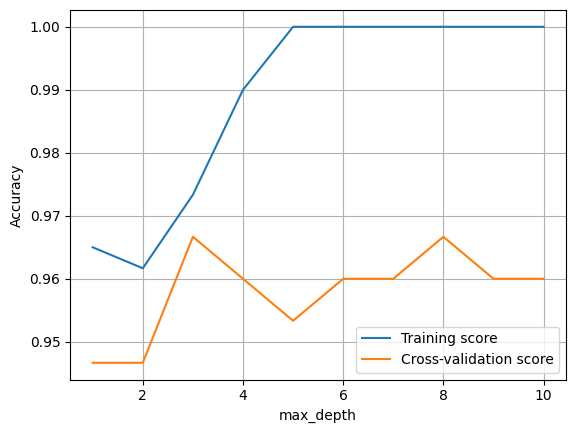

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

# We want to see how 'max_depth' affects the model
param_range = np.arange(1, 11)

train_scores, test_scores = validation_curve(
    RandomForestClassifier(), 
    X, 
    y, 
    param_name="max_depth",  # The hyperparameter to test
    param_range=param_range, 
    cv=5,
    scoring="accuracy"
)

# Calculate means
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# Plotting
plt.plot(param_range, train_mean, label="Training score")
plt.plot(param_range, test_mean, label="Cross-validation score")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()

#### LogisticRegression:

In [11]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split, validation_curve
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris

In [12]:
# load data
data = load_iris()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver='lbfgs',
                           max_iter=1000,
                           random_state=42)
)

In [17]:
param_range = [0.001, 0.01, 0.1, 1.1, 100, 1000]

In [18]:
train_score, test_score = validation_curve(
    pipe_lr,
    X = X_train,
    y = y_train,
    param_name = 'logisticregression__C',
    param_range = param_range,
    cv = 10
)

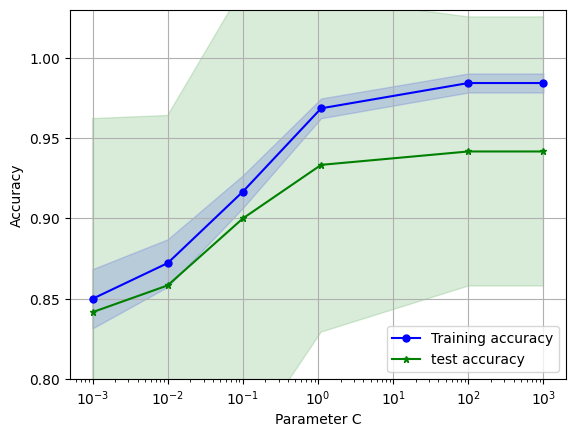

In [19]:
train_mean = train_score.mean(axis=1)
train_std = train_score.std(axis=1)
test_mean = test_score.mean(axis=1)
test_std = test_score.std(axis=1)

plt.plot(param_range, train_mean, color='blue', marker='o',
         markersize=5, label='Training accuracy')
plt.fill_between(param_range,
                 train_mean + train_std,   # y1 — upper edge
                 train_mean - train_std,   # y2 — lower edge
                 alpha=0.15, color='blue')

plt.plot(param_range, test_mean, color='green', marker='*',
         markersize=5, label='test accuracy')
plt.fill_between(param_range,
                 test_mean + test_std,   # y1 — upper edge
                 test_mean - test_std,   # y2 — lower edge
                 alpha=0.15, color='green')

plt.grid()
plt.xlabel('Parameter C')
# on a linear scale, the distance between 1 to 10 is the same as between 10 and 19. 
# On a log scale, the distance between 1 and 10 is the same as between 10 and 100, and 100 and 1000. 
plt.xscale('log') 
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.8, 1.03])
plt.show()

In a validation curve, the "best" value is not necessarily the one where accuracy is highest, but the one where the **gap between training and test accuracy is minimized while maintaining high performance.**

Based on your specific plot, here is the analysis:

#### 1. The Analysis of your Plot
*   **Training Accuracy (Blue):** It increases steadily and plateaus around $C=10^2$ to $10^3$ at nearly $0.98$.
*   **Test Accuracy (Green):** It increases and plateaus around $C=1$ to $C=10^3$ at approximately $0.94$.
*   **The Gap (Variance):** The shaded area (the difference between training and test) is quite large across the entire range, but it is **widest** at the lower values of $C$ and **narrowest** at the higher values of $C$.

#### 2. Identifying the "Best" Value
In machine learning, you are looking for the **elbow** or the point where the test accuracy stops improving significantly, but before the training accuracy and test accuracy diverge too wildly.

*   **If you prioritize maximum accuracy:** The best value is **$C=1$ or $C=10$**. At these points, the test accuracy has reached its peak ($\approx 0.94$), but the gap between training and test accuracy is much smaller than it is at $C=10^3$.
*   **If you prioritize generalization (Robustness):** The best value is **$C=1$**. Looking at the green line, it reaches its maximum plateau around $C=1$. Moving from $C=1$ to $C=1000$ provides almost zero benefit to the test accuracy, but it makes the model "overfit" more (the blue line keeps climbing while the green line stays flat).

#### 3. Summary Decision
**The best value is $C=1$.**

**Reasoning:**
1.  **Performance:** It achieves the maximum test accuracy shown in the plot ($\approx 0.94$).
2.  **Generalization:** It avoids the "overfitting trap." At $C=100$ or $C=1000$, your training accuracy is much higher than your test accuracy, meaning the model is just memorizing the training data without gaining any real predictive power on new data. 

**Rule of Thumb:** Always pick the simplest model (the smallest $C$ in this case) that achieves the highest test accuracy. This is known as **Occam's Razor**.